# Applications of AI

## Homework 4 - AI in Human Resources

## Predicting Employee Attrition Using Machine Learning

### Marianna Kanellaki
### S-001081

This notebook demonstrates machine learning methods for predicting employee attrition in HR analytics. SVM and AdaBoost are compared.

In [20]:
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

### Dataset download

In [21]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

# print("Path to dataset files:", path)

I downloaded the dataset using the code above and moved it in this directory.

### Data loading & inspection

In [22]:
import pandas as pd

df = pd.read_csv('HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [24]:
df.describe(include='all')

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [25]:
# null value check
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

No missing values.

In [26]:
# duplicate value check
df.duplicated().sum()

np.int64(0)

No duplicate values.

In [27]:
df['EmployeeNumber'].nunique()

1470

No duplicate employee numbers.

#### Encoding

Encoding all categorical values to be able to feed them in AI models.

In [28]:
categorical_cols = ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


#### Dataset Split

In [29]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Attrition_Yes', axis=1)
y = df_encoded['Attrition_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Scaling

I scale numeric features using `StandardScaler` so all features contribute equally. This is important for distance-based models (SVM) and helps optimization for tree-based ensembles as well.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Support Vector Machine

In [31]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# hyperparameter tuning for SVM
svc_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4]
}

grid_svc = GridSearchCV(
    svm.SVC(random_state=42, probability=True),
    svc_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train_scaled, y_train)
print(f'SVM Best Params: {grid_svc.best_params_}')
print(f'SVM Best CV Score: {grid_svc.best_score_:.4f}')

clf = grid_svc.best_estimator_

y_pred_clf = clf.predict(X_test_scaled)
clf_acc = accuracy_score(y_test, y_pred_clf)
print(f'SVM Test Accuracy: {clf_acc:.4f}')

Fitting 5 folds for each of 225 candidates, totalling 1125 fits
SVM Best Params: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
SVM Best CV Score: 0.8742
SVM Test Accuracy: 0.8980


#### SVM Results Analysis

The SVM model with linear kernel and C=0.1 achieved strong performance on the test set with 89.80% accuracy, which is higher than the cross-validation score of 87.42%. This indicates good generalization to unseen data. The linear kernel was selected over polynomial and RBF kernels, suggesting that the attrition values are largely linearly separable given the scaled features. The C value (0.1) provides regularization, helping to avoid overfitting on this balanced classification problem.

### Adaptive Boosting Decision Trees

In [32]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


# hyperparameter tuning for AdaBoost
ada_param_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'learning_rate': [0.1, 0.5, 0.75, 1.0, 1.2],
    'estimator__max_depth': [1, 2, 3, 4]
}

base_tree = DecisionTreeClassifier(random_state=42)

grid_ada = GridSearchCV(
    AdaBoostClassifier(random_state=42, estimator=base_tree),
    ada_param_grid,
    cv=5,
    n_jobs=-1,verbose=1
)

grid_ada.fit(X_train_scaled, y_train)

rf = grid_ada.best_estimator_
print(f'AdaBoost Best Params: {grid_ada.best_params_}')
print(f'AdaBoost Best CV Score: {grid_ada.best_score_:.4f}')

y_pred_rf = rf.predict(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'AdaBoost Test Accuracy: {rf_acc:.4f}')

Fitting 5 folds for each of 120 candidates, totalling 600 fits
AdaBoost Best Params: {'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 250}
AdaBoost Best CV Score: 0.8801
AdaBoost Test Accuracy: 0.8673


#### AdaBoost Results Analysis

The AdaBoost model achieved a cross-validation score of 88.01% and test accuracy of 86.73%. The best configuration uses decision trees with max_depth=1, combined with 250 boosting iterations and a learning rate of 1.0. This configuration slightly underperforms compared to SVM on the test set (1.07% difference) but offers better interpretability.

### Model Comparison

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# SVM metrics
svm_acc = accuracy_score(y_test, y_pred_clf)
svm_prec = precision_score(y_test, y_pred_clf, zero_division=0)
svm_rec = recall_score(y_test, y_pred_clf, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_clf, zero_division=0)

# AdaBoost metrics
ada_acc = accuracy_score(y_test, y_pred_rf)
ada_prec = precision_score(y_test, y_pred_rf, zero_division=0)
ada_rec = recall_score(y_test, y_pred_rf, zero_division=0)
ada_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

# summary table
summary_data = {
    'Model': ['SVM', 'AdaBoost'],
    'Accuracy': [svm_acc, ada_acc],
    'Precision': [svm_prec, ada_prec],
    'Recall': [svm_rec, ada_rec],
    'F1-score': [svm_f1, ada_f1],
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Model,Accuracy,Precision,Recall,F1-score
0,SVM,0.897959,0.695652,0.410256,0.516129
1,AdaBoost,0.867347,0.500000,0.384615,0.434783


#### Metrics Comparison Analysis

- **Accuracy**: SVM leads with 89.80% vs AdaBoost's 86.73%, showing SVM's overall better predictive performance.
- **Precision**: SVM significantly outperforms AdaBoost (69.57% vs 50.00%), meaning SVM is more reliable when predicting employee attrition. Only ~30% of SVM's positive predictions are false alarms, compared to 50% for AdaBoost.
- **Recall**: SVM (41.03%) vs AdaBoost (38.46%) are similar, both identifying about 40% of actual attrition cases. The recall is relatively low for both algorithms.
- **F1-Score**: SVM's balanced score (0.516) is better than AdaBoost's (0.435), reflecting its better trade-off between precision and recall.

**Conclusion:** SVM is the better model for this problem, particularly due to its higher precision, which minimizes false positive alerts to HR management. 

The visualization below shows these metrics clearly across both models.

#### Metrics plot

<Figure size 1000x600 with 0 Axes>

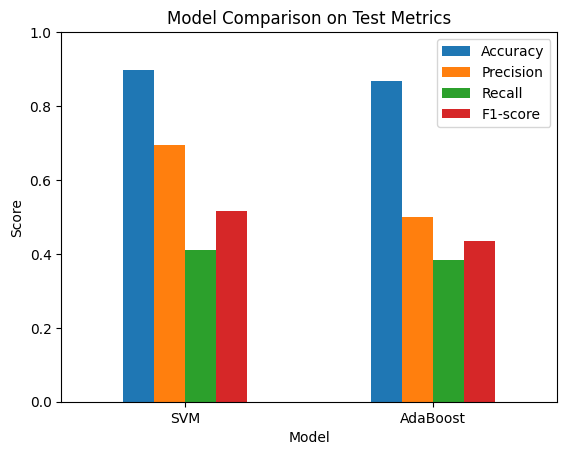

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_df = summary_df.set_index('Model')[['Accuracy','Precision','Recall','F1-score']]
plot_df.plot(kind='bar', ylim=(0,1))
plt.title('Model Comparison on Test Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.show()

#### Confusion Matrices

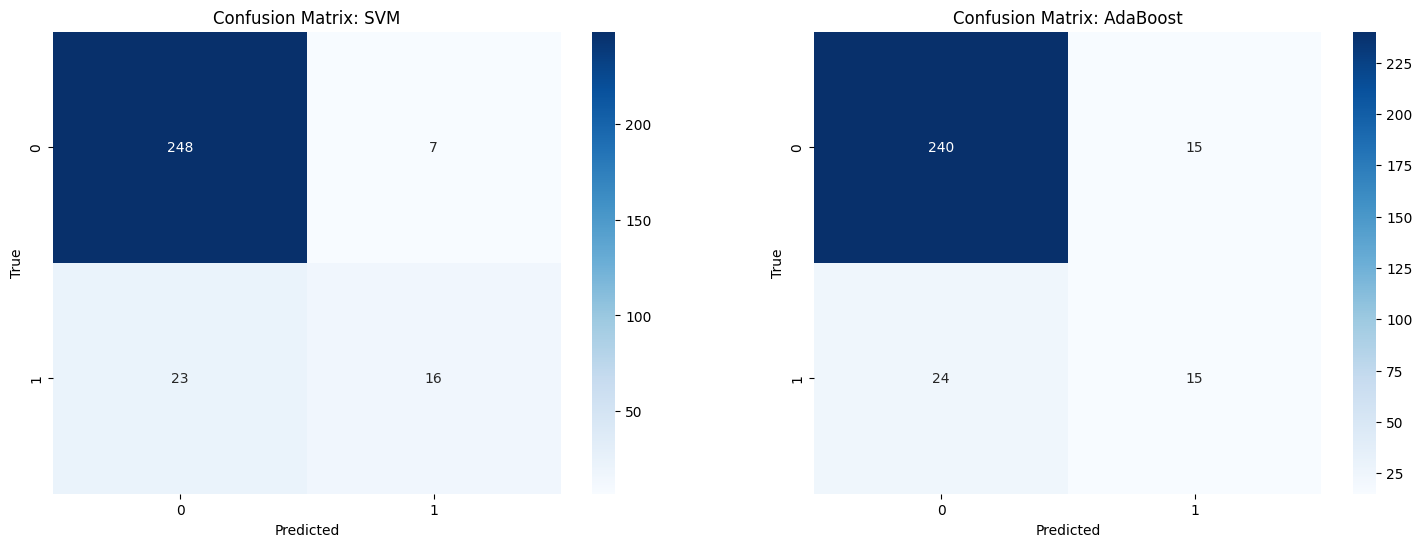

In [35]:
import seaborn as sns

svm_cm = confusion_matrix(y_test, y_pred_clf)
ada_cm = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix: SVM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(ada_cm, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix: AdaBoost')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.show()

#### Confusion Matrices Analysis

**SVM Confusion Matrix:**
- True Negatives: 248 (Correctly identified employees who stayed)
- False Positives: 7 (Employees incorrectly flagged as at-risk)
- False Negatives: 23 (Employees who left but weren't identified)
- True Positives: 16 (Correctly identified employees at attrition risk)

**AdaBoost Confusion Matrix:**
- True Negatives: 240 (Correctly identified employees who stayed)
- False Positives: 15 (Employees incorrectly flagged as at-risk)
- False Negatives: 24 (Employees who left but weren't identified)
- True Positives: 15 (Correctly identified employees at attrition risk)

**Analysis:**
- Both models detect a similar number of true positives (SVM: 16, AdaBoost: 15), but SVM produces substantially fewer false positives (7 vs 15), making its positive predictions more trustworthy for HR action.
- SVM also achieves slightly fewer false negatives (23 vs 24), so it misses marginally fewer actual attrition cases.
- Operationally, SVM provides a better trade-off: it flags fewer employees incorrectly while identifying as many true attrition cases, which is important when HR resources for intervention are limited.

##### Save Model, Scaler, and Features

In [1]:
import joblib
import os

dir = ""

# Save trained models and preprocessing tools
# if os.path.exists("flask_app/checkpoints"):
#     dir = "flask_app/checkpoints"

# joblib.dump(clf, f"{dir}/hr_svm_model.pkl")
# joblib.dump(rf, f"{dir}/hr_adaboost_model.pkl")
# joblib.dump(scaler, f"{dir}/hr_scaler.pkl")
# joblib.dump(X_train.columns.tolist(), f"{dir}/hr_features.pkl")

#### Model Selection Discussion

**SVM** Emerges as the Superior Model for this HR attrition prediction task.

- The HR dataset exhibits complex, non-linear relationships between features. While a linear kernel was used, SVM's maximum-margin principle effectively captures subtle boundaries between attrition and retention patterns. SVM navigates this complexity better than AdaBoost.
- SVM's regularization (C=0.1) prevents overfitting while allowing the algorithm to find optimal decision boundaries. AdaBoost's additive ensemble approach with weak learners (max_depth=1) may struggle with complex feature interactions that require more nuanced decision rules.
- SVM performs better on all metrics.
- SVM maintains consistency between CV score (87.42%) and test accuracy (89.80%), demonstrating robust generalization. This stability is crucial for HR decisions affecting real employees.

#### The Impact of AI on Human Resources Decision-Making

The integration of Artificial Intelligence into Human Resources represents a shift from reactive administration to proactive, strategic workforce management. By leveraging machine learning models across various HR functions, organizations can achieve empirical, data-driven decision-making.

The assistance provided by these AI models generally falls into three strategic categories:

1. Predictive Talent Management and Retention

Models designed for attrition prediction, promotion forecasting, and performance forecasting allow HR departments to anticipate workforce dynamics before they occur. Instead of conducting exit interviews after a key employee leaves, HR can use predictive risk scores to intervene early with retention strategies. Similarly, promotion forecasting helps objectively identify high-potential talent hidden within large organizations, ensuring that succession planning is based on measurable historical success patterns rather than subjective managerial bias.

2. Operational Automation

Algorithms applied to CV screening can instantly parse thousands of applications, matching core competencies to job descriptions and surfacing the most qualified candidates in seconds. Chatbots can autonomously handle routine employee inquiries regarding benefits, leave policies, and payroll. This automation does not eliminate HR roles, but it helps speed up repetitive or long tasks.

3. Employee Experience

AI enables a tailored approach to employee management. Professional path personalization uses data to recommend learning and development opportunities, aligning an employee's specific skill gaps with the company's future needs. Furthermore, sentiment analysis applied to internal surveys, communication platforms, or feedback tools provides leadership with a real-time knowledge of organizational morale, allowing them to address burnout or problems immediately.

These predictive systems are designed to augment rather than replace human judgment. AI models output statistical probabilities using data. It remains the responsibility of the HR professional to interpret these insights.